k = 2 | Silhouette Score = 0.3842
k = 3 | Silhouette Score = 0.4610
k = 4 | Silhouette Score = 0.4926
k = 5 | Silhouette Score = 0.5538
k = 6 | Silhouette Score = 0.5387
k = 7 | Silhouette Score = 0.5198
k = 8 | Silhouette Score = 0.4309
k = 9 | Silhouette Score = 0.4377
k = 10 | Silhouette Score = 0.4339


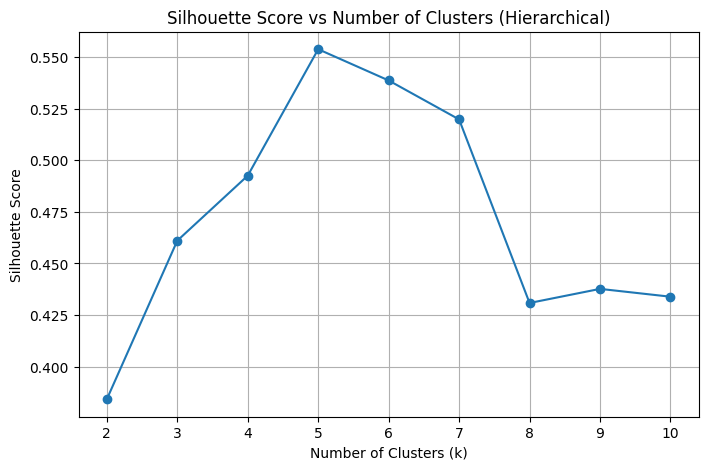


Best number of clusters: 5


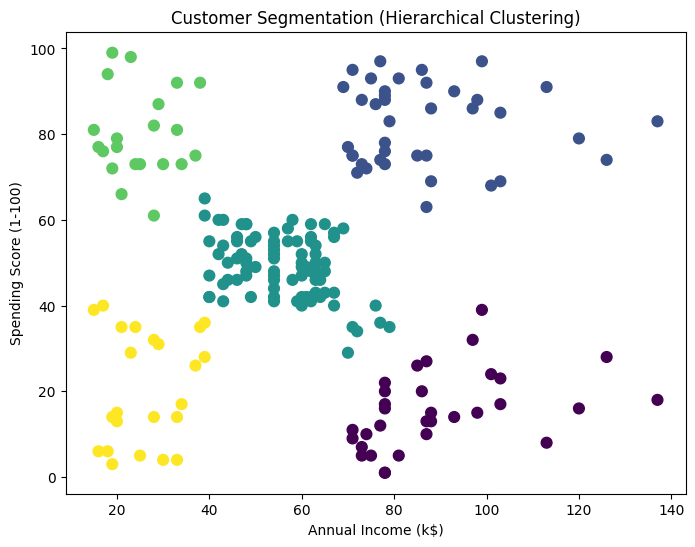

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# -------------------------
# 1. Load dataset
# -------------------------
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv"

df = pd.read_csv(url)

# -------------------------
# 2. Select correct columns
# -------------------------
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# -------------------------
# 3. Feature scaling
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 4. Try different cluster values
# -------------------------
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"k = {k} | Silhouette Score = {score:.4f}")

# -------------------------
# 5. Plot Silhouette Scores
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(list(k_range), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters (Hierarchical)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

# -------------------------
# 6. Best k selection
# -------------------------
best_k = k_range[np.argmax(silhouette_scores)]
print("\nBest number of clusters:", best_k)

# -------------------------
# 7. Final model
# -------------------------
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster'] = final_model.fit_predict(X_scaled)

# -------------------------
# 8. Visualization
# -------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.title("Customer Segmentation (Hierarchical Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

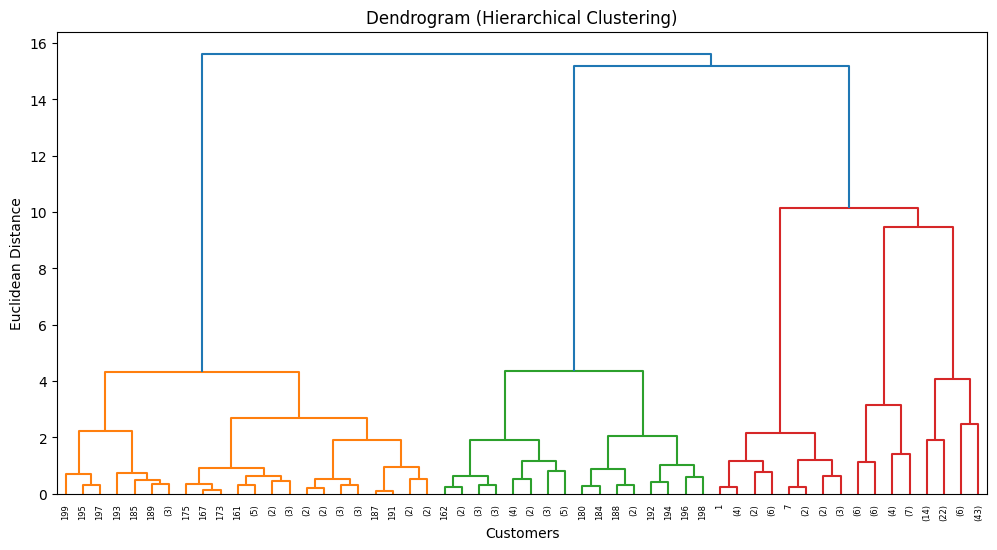

Best k from Silhouette Score: 5


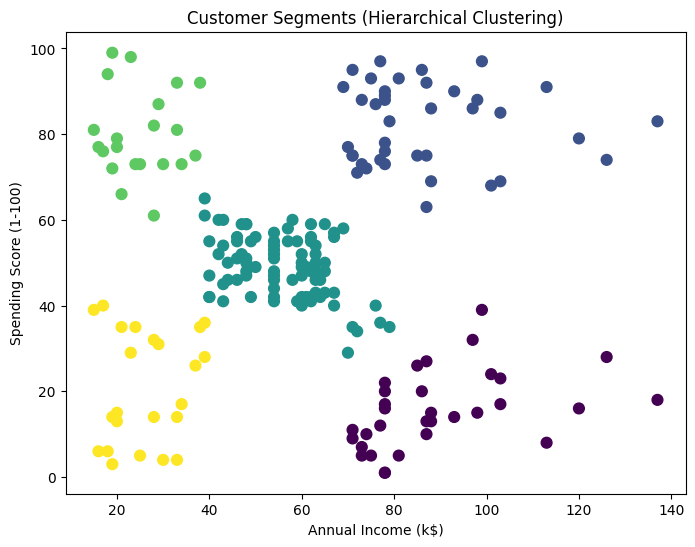

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# -------------------------
# 1. Load dataset
# -------------------------
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv"

df = pd.read_csv(url)

# -------------------------
# 2. Select features
# -------------------------
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# -------------------------
# 3. Scaling
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 4. DENDROGRAM (IMPORTANT STEP)
# -------------------------
plt.figure(figsize=(12, 6))

linked = linkage(X_scaled, method='ward')

dendrogram(
    linked,
    truncate_mode='level',   # simplifies large tree
    p=5,                     # shows last 5 merges
)

plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

# -------------------------
# 5. Silhouette Score to confirm k
# -------------------------
k_range = range(2, 11)
sil_scores = []

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

best_k = k_range[np.argmax(sil_scores)]
print("Best k from Silhouette Score:", best_k)

# -------------------------
# 6. Final clustering using best k
# -------------------------
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster'] = final_model.fit_predict(X_scaled)

# -------------------------
# 7. Final visualization
# -------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.title("Customer Segments (Hierarchical Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

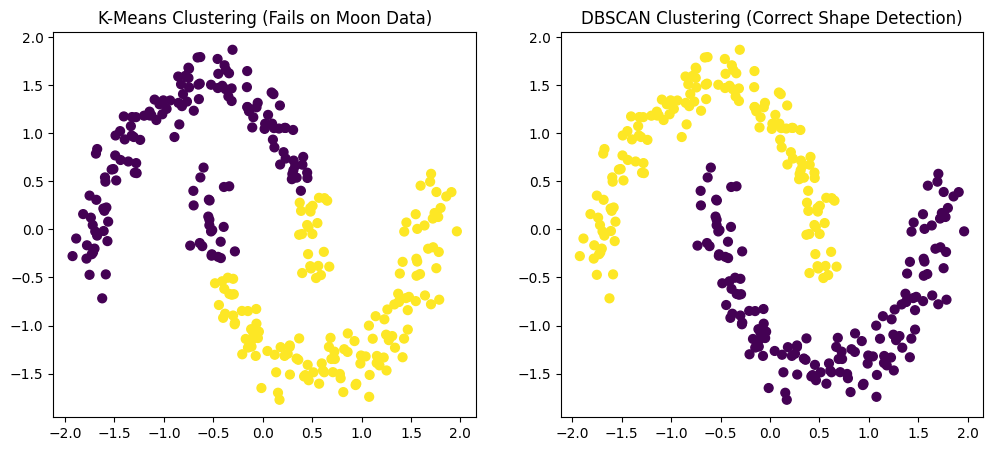

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1. Create Moon dataset
# -------------------------
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)

# -------------------------
# 2. Scale data (important for DBSCAN)
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3. K-Means clustering
# -------------------------
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# -------------------------
# 4. DBSCAN clustering
# -------------------------
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# -------------------------
# 5. Visualization
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- KMeans plot ----
axes[0].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=40
)
axes[0].set_title("K-Means Clustering (Fails on Moon Data)")

# ---- DBSCAN plot ----
axes[1].scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=40
)
axes[1].set_title("DBSCAN Clustering (Correct Shape Detection)")

plt.show()

## Inter Cluster Distance in Hierarchical Clustering
![](https://dataaspirant.com/wp-content/uploads/2020/12/15-Hierarchical-Clustering-Linkages.png)